# TODO: ModelMeta Notebook Follow-up

`ModelMeta` now expects `platform_number`, `cycle_number`, and `direction` as separate fields and derives `cycle_id` from them.

This notebook likely still carries assumptions from the older cycle-id-driven setup, so it needs a follow-up pass to align the notebook logic and commentary with the refactor before treating it as settled.


# Uncertainty Extension Sketch

This notebook is a first pass at extending the Jana-style profile workflow into a local weighted reconstruction problem. The idea is to pick one cycle, remove it from the donor set, interpolate nearby cycles onto the same pressure grid, and combine those donors with simple spatial and temporal weights.

The current goal is interpretability rather than a finalized benchmark. This is mainly a check on whether the local weighted profile looks physically plausible and whether the donor cloud hints at structure that a simple distance-only weighting might miss.


In [1]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import pickle
from pathlib import Path
from scipy import stats
from dataclasses import dataclass, field
from typing import Iterator, Self, Optional
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt, timedelta as td

In [2]:
from argo_interp.data import data_filter, get_data
from argo_interp.cycle.adapter import PchipAdapter
from argo_interp.cycle.model import Model
from argo_interp.cycle.domain import ModelData, ModelMeta
from argo_interp.cycle.config import ModelSettings, ModelKwargs
from argo_interp.model import CycleModels

/home/jcherry/Documents/git/argo-data-interpolation/.venv/bin/python: No module named pip


In [3]:
data_path = Path('./data')
data_path.mkdir(exist_ok=True)

data_file = data_path / 'uncertainty_extension-argo_data.pkl'

In [4]:
override = False

if data_file.exists() and not override:
    with data_file.open('br') as f:
        ds = pickle.load(f)
else:
    box = [
        80, 99, ## Longitude min/max
        6, 23, ## Latitude min/max
        0, 750, ## Pressure min/max
        '2011-01-01', '2020-12-31', ## Datetime min/max
    ]
    ds = get_data(box, progress=True)

    with data_file.open('bw') as f:
        pickle.dump(ds, f)

In [5]:
settings = ModelSettings(n_folds=5)

In [6]:
cycle_models = {}
cycle_data_actuals = {}

cycles = len(ds[['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'DIRECTION']].to_dataframe().drop_duplicates())
t = tqdm(ds.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'DIRECTION']), total=cycles)
for (platform_number, cycle_number, direction), cycle_ds in t:
    pressure = cycle_ds['PRES'].values
    temperature = cycle_ds['TEMP'].values
    salinity = cycle_ds['PSAL'].values

    latitude = cycle_ds['LATITUDE'].values[0]
    longitude = cycle_ds['LONGITUDE'].values[0]
    timestamp = cycle_ds['TIME'].values[0]

    if cycle_ds.sizes['N_POINTS'] < 3:
        continue

    model_data = ModelData(
        pressure=pressure,
        temperature=temperature,
        salinity=salinity,
    ).clean_duplicates('mean')

    model_meta = ModelMeta(
        platform_number=str(int(platform_number)),
        cycle_number=str(int(cycle_number)),
        direction=direction,
        latitude=latitude,
        longitude=longitude,
        timestamp=timestamp,
        profile_pressure=(pressure.min(), pressure.max()),
    )
    cycle_id = model_meta.cycle_id

    model = Model.build(model_meta, model_data, PchipAdapter, settings)
    cycle_models[cycle_id] = model
    cycle_data_actuals[cycle_id] = model_data
    t.set_postfix(model_count=len(cycle_models))
cycle_models = CycleModels(models=cycle_models)

  0%|          | 0/21005 [00:00<?, ?it/s]

## Local donor selection and weighting

The next cells define the neighborhood and the weighting pieces. The current version uses three factors:
- geographic distance inside a local latitude/longitude window
- seasonal alignment using cyclical week-of-year distance
- broader interannual time separation

That is a pragmatic starting point for a spatio-temporal kernel. It stays simple enough that the behavior of each term is still easy to inspect.


In [7]:
dist_range = 2
dist_stdev_cutoff = 3

week_range = 8
week_stdev_cutoff = 3

annual_stdev = 2

In [8]:
def calc_weight(x2: ArrayLike | float, var: ArrayLike | float) -> ArrayLike | float:
    return np.exp(-x2 / (2 * var))

In [9]:
cycle_id = np.random.choice(cycle_models.index.index)
cycle_meta = cycle_models.index.loc[cycle_id]
print(cycle_id)

6901562-137-A


In [10]:
active_cycle_data = cycle_data_actuals[cycle_id]

In [11]:
lat_filter = [cycle_meta['latitude'] - (dist_range / 2),
              cycle_meta['latitude'] + (dist_range / 2)]

long_filter = [cycle_meta['longitude'] - (dist_range / 2),
               cycle_meta['longitude'] + (dist_range / 2)]

cycle_filter = [cycle_meta['timestamp'] - td(weeks=week_range / 2),
                cycle_meta['timestamp'] + td(weeks=week_range / 2)]

subcycle_models = cycle_models.filter(lat_filter, long_filter, cyclical_dates=cycle_filter)
subcycle_models.pop(cycle_id)
interp_data = subcycle_models.interpolate(active_cycle_data.pressure)

In [12]:
dist_numer_sq = np.pow(subcycle_models.index[['latitude', 'longitude']] - cycle_meta[['latitude', 'longitude']].astype(float), 2).sum(axis=1)
dist_stdev = (dist_range / 2) / dist_stdev_cutoff
dist_weight = calc_weight(dist_numer_sq, dist_stdev ** 2)

In [13]:
week_seconds_sq = (subcycle_models.index['timestamp'].apply(lambda x: x.replace(year=2000)) - cycle_meta['timestamp'].replace(year=2000)) \
                      .dt.total_seconds() ** 2
seconds_in_week = 60 * 60 * 24 * 7
week_seconds_stdev = (week_range / 2) / week_stdev_cutoff * seconds_in_week
week_seconds_weight = calc_weight(week_seconds_sq, week_seconds_stdev ** 2)

In [14]:
seconds_delta_sq = (subcycle_models.index['timestamp'] - cycle_meta['timestamp']).dt.total_seconds() ** 2
seconds_in_year = 60 * 60 * 24 * 365.25
seconds_delta_stdev = annual_stdev * seconds_in_year
seconds_delta_weight = calc_weight(seconds_delta_sq, seconds_delta_stdev ** 2)

In [15]:
weights = dist_weight * week_seconds_weight * seconds_delta_weight
weights /= weights.max()

## Weighted reconstruction of the held-out cycle

Here the donor profiles are combined into one predicted temperature and salinity profile on the held-out cycle's pressure grid. The quick mean-squared-error check below is only a sanity check; the plot matters more because it shows whether the prediction is sitting inside one coherent donor family or averaging across multiple local regimes.


In [16]:
temp_weight = interp_data.temperature.notnull() * dist_weight * week_seconds_weight * seconds_delta_weight
sal_weight = interp_data.salinity.notnull() * dist_weight * week_seconds_weight * seconds_delta_weight

predicts = pd.DataFrame({
    'temperature': (interp_data.temperature * temp_weight).sum(axis=1) / temp_weight.sum(axis=1),
    'salinity': (interp_data.salinity * sal_weight).sum(axis=1) / sal_weight.sum(axis=1),
})

errors = active_cycle_data.to_frame().set_index('pressure') - predicts

In [17]:
(errors ** 2).mean(axis=0)

temperature    2.720217
salinity       0.119992
dtype: float64

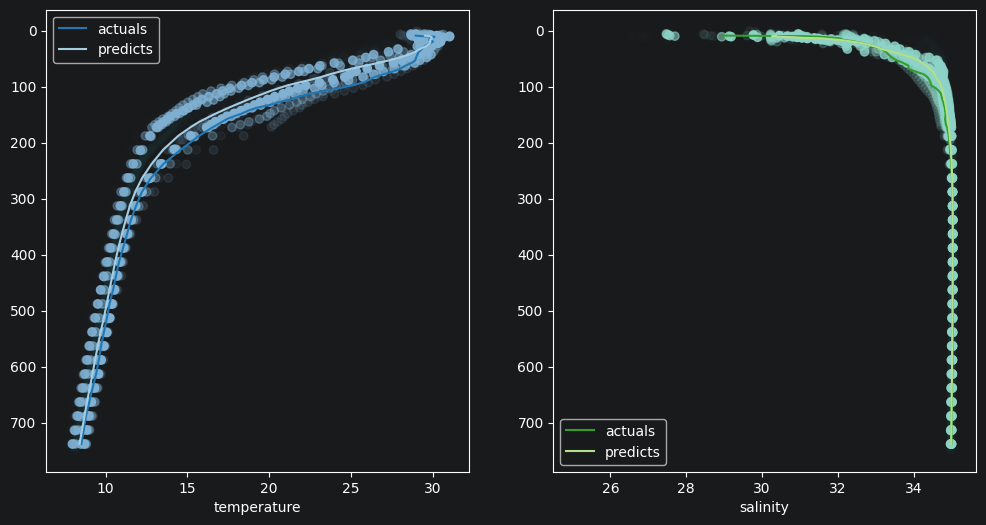

In [33]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

actuals = active_cycle_data.to_frame()

interp_actuals = pd.concat([
    pd.concat([
        cycle_data_actuals[cycle_id].to_frame(),
        pd.Series([weights[cycle_id]] * len(cycle_data_actuals[cycle_id]), name='weight')
    ], axis=1) for cycle_id in subcycle_models.models.keys()
], axis=0, ignore_index=True)

actuals.plot(x='temperature', y='pressure', ax=ax[0], label='actuals', color='#1f78b4')
predicts.reset_index().plot(x='temperature', y='index', ax=ax[0], label='predicts', color='#a6cee3')
ax[0].scatter(x=interp_actuals['temperature'], y=interp_actuals['pressure'],
              color='#80b1d3', alpha=interp_actuals['weight'])
ax[0].invert_yaxis()

actuals.plot(x='salinity', y='pressure', ax=ax[1], label='actuals', color='#33a02c')
predicts.reset_index().plot(x='salinity', y='index', ax=ax[1], label='predicts', color='#b2df8a')
ax[1].scatter(x=interp_actuals['salinity'], y=interp_actuals['pressure'],
              color='#8dd3c7', alpha=interp_actuals['weight'])
ax[1].invert_yaxis()

## Interpretation and next step

The final temperature panel looks like it may contain two separate threadlines rather than one diffuse cloud. My current conjecture is that this split is more likely tied to ocean-current structure or distinct local water-mass pathways than to interpolation noise alone.

If that read is right, a useful next check would be to look at float positions over time and ask whether the trajectory geometry can be used as a rough measure of the local gradient field. That could give a better physical basis for the distance and positioning weights, instead of treating proximity as purely isotropic in latitude, longitude, and time.
